# FAPE, Student Performance Baseline Models
## Education Domain, Sex Fairness Evaluation

**Datasets:** Student Performance, Cortez & Silva (2008), UCI ML Repository  
**Math:** 395 records | **Portuguese:** 649 records  
**Models:** Logistic Regression, Random Forest, Gradient Boosting  
**Sensitive:** sex (0=Female, 1=Male), age (2 bins)  

**Key findings:**
- Math AUC=0.680 (GB), lower than Portuguese; Math has 395 records against 649
- Portuguese AUC=0.850 (RF)
- **Sex gap reverses between subjects**, Math: males over-predicted, Portuguese: females over-predicted
- All DIR ratios below the 0.8 four-fifths convention
- Stage 2 ThresholdOptimizer needed across both subjects

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, roc_curve
from student_loader import load_student_performance
from baseline_student import fairness_metrics

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
os.makedirs('../figures/baseline', exist_ok=True)
MODEL_COLORS = {'LogisticRegression':'steelblue','RandomForest':'coral','GradientBoosting':'#5cb85c'}
SUBJECT_COLORS = {'math':'steelblue','portuguese':'coral'}
print('Imports complete')

Imports complete


In [2]:
datasets = load_student_performance()
MODELS_NB = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}
all_results = {}
for subject, ds in datasets.items():
    X=ds['X'].values; y=ds['y'].values
    sex=ds['X']['sex'].values; age=ds['X']['age'].values
    age_binned=pd.cut(age,bins=2,labels=['young','older']).astype(str)
    X_train,X_test,y_train,y_test,idx_tr,idx_te=train_test_split(X,y,np.arange(len(y)),test_size=0.2,random_state=42,stratify=y)
    sex_test=sex[idx_te]; age_test=age_binned[idx_te]
    scaler=StandardScaler(); X_tr_sc=scaler.fit_transform(X_train); X_te_sc=scaler.transform(X_test)
    subj_results={}
    for name,model in MODELS_NB.items():
        if name=='LogisticRegression':
            model.fit(X_tr_sc,y_train); y_pred=model.predict(X_te_sc); y_prob=model.predict_proba(X_te_sc)[:,1]
        else:
            model.fit(X_train,y_train); y_pred=model.predict(X_test); y_prob=model.predict_proba(X_test)[:,1]
        auc=roc_auc_score(y_test,y_prob); f1=f1_score(y_test,y_pred)
        fm_sex=fairness_metrics(y_test,y_pred,sex_test)
        fm_age=fairness_metrics(y_test,y_pred,age_test)
        dp_diffs=[abs(v['dp_diff']) for v in fm_sex.values()]
        subj_results[name]={'auc':auc,'f1':f1,'y_pred':y_pred,'y_prob':y_prob,'y_test':y_test,
                            'fairness_sex':fm_sex,'fairness_age':fm_age,'max_dp':max(dp_diffs) if dp_diffs else 0}
    all_results[subject]={'results':subj_results,'sex_test':sex_test,'age_test':age_test,'y_test':y_test,'X':ds['X'],'y':ds['y']}
    print(f'{subject}: done')
print('All baselines complete')

  Downloaded: student-mat (395 rows), student-por (649 rows)
  OK: student_math: 395 rows | 30 features | positive rate: 0.410 | median grade: 11.0
  OK: student_portuguese: 649 rows | 30 features | positive rate: 0.425 | median grade: 12.0


math: done


portuguese: done
All baselines complete


## 1. Model Comparison, AUC and F1 by Subject

Portuguese AUC=0.850 vs Math AUC=0.680. Portuguese has 649 records and Math 395, though the subjects also differ, so size is not the only explanation.

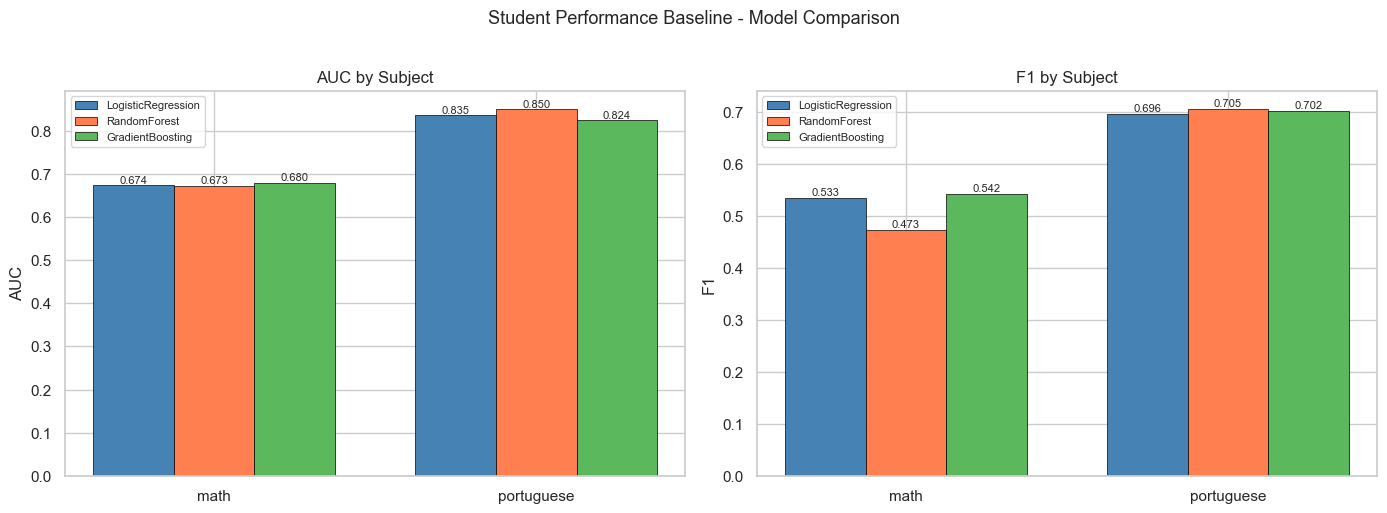

In [3]:
subjects=list(all_results.keys()); x=np.arange(len(subjects)); width=0.25
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
for i,name in enumerate(MODELS_NB.keys()):
    aucs=[all_results[s]['results'][name]['auc'] for s in subjects]
    f1s=[all_results[s]['results'][name]['f1'] for s in subjects]
    bars1=ax1.bar(x+i*width,aucs,width,label=name,color=MODEL_COLORS[name],edgecolor='black',linewidth=0.5)
    bars2=ax2.bar(x+i*width,f1s,width,label=name,color=MODEL_COLORS[name],edgecolor='black',linewidth=0.5)
    for bar,val in zip(bars1,aucs): ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,f'{val:.3f}',ha='center',fontsize=8)
    for bar,val in zip(bars2,f1s): ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,f'{val:.3f}',ha='center',fontsize=8)
for ax,metric in [(ax1,'AUC'),(ax2,'F1')]:
    ax.set_xticks(x+width); ax.set_xticklabels(subjects)
    ax.set_title(f'{metric} by Subject',fontsize=12); ax.set_ylabel(metric); ax.legend(fontsize=8)
plt.suptitle('Student Performance Baseline - Model Comparison',fontsize=13,y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/student_model_comparison.png',dpi=150,bbox_inches='tight')
plt.show()

## 2. ROC Curves, Both Subjects

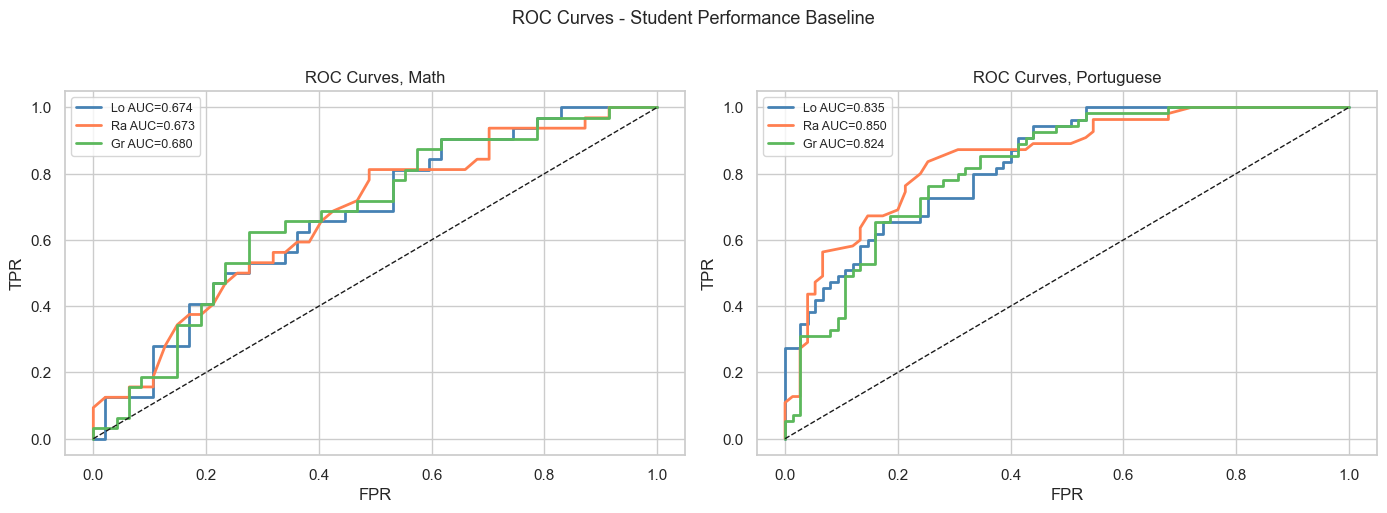

In [4]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
for ax,subject in [(ax1,'math'),(ax2,'portuguese')]:
    for name,color in MODEL_COLORS.items():
        res=all_results[subject]['results'][name]
        fpr_c,tpr_c,_=roc_curve(res['y_test'],res['y_prob'])
        ax.plot(fpr_c,tpr_c,label=f'{name[:2]} AUC={res["auc"]:.3f}',color=color,linewidth=2)
    ax.plot([0,1],[0,1],'k--',linewidth=1)
    ax.set_title(f'ROC Curves, {subject.capitalize()}',fontsize=12)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(fontsize=9)
plt.suptitle('ROC Curves - Student Performance Baseline',fontsize=13,y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/student_roc_curves.png',dpi=150,bbox_inches='tight')
plt.show()

## 3. Sex FPR/TPR, Math

Math: Males over-predicted (higher FPR and TPR). Females systematically under-predicted.

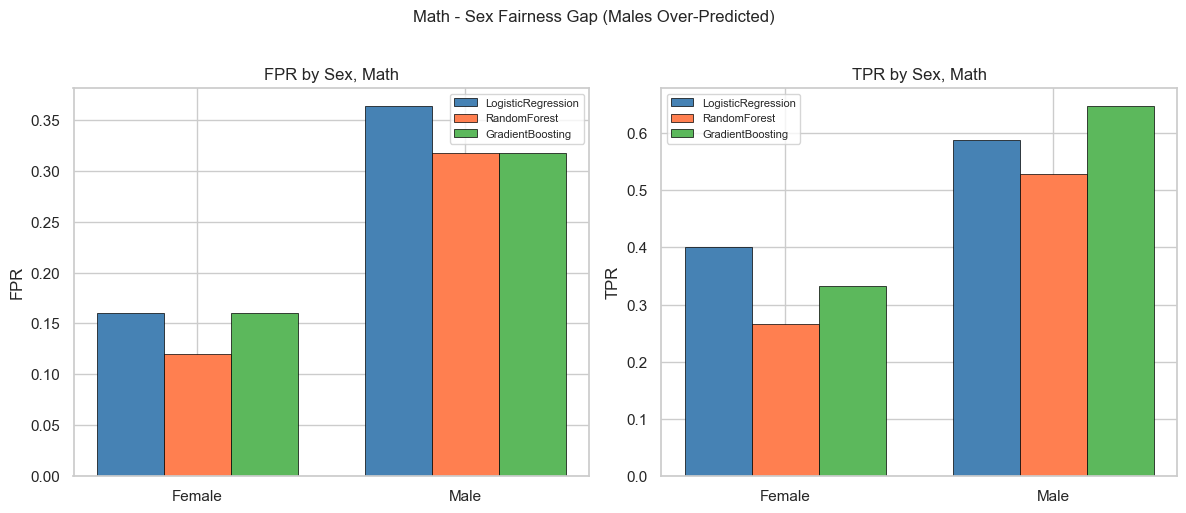

In [5]:
x=np.arange(2); width=0.25
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
for i,name in enumerate(MODELS_NB.keys()):
    fm=all_results['math']['results'][name]['fairness_sex']
    fprs=[fm.get(g,{}).get('fpr',0) for g in [0,1]]
    tprs=[fm.get(g,{}).get('tpr',0) for g in [0,1]]
    ax1.bar(x+i*width,fprs,width,label=name,color=MODEL_COLORS[name],edgecolor='black',linewidth=0.5)
    ax2.bar(x+i*width,tprs,width,label=name,color=MODEL_COLORS[name],edgecolor='black',linewidth=0.5)
for ax,metric in [(ax1,'FPR'),(ax2,'TPR')]:
    ax.set_xticks(x+width); ax.set_xticklabels(['Female','Male'])
    ax.set_title(f'{metric} by Sex, Math',fontsize=12); ax.set_ylabel(metric); ax.legend(fontsize=8)
plt.suptitle('Math - Sex Fairness Gap (Males Over-Predicted)',fontsize=12,y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/student_math_sex_fairness.png',dpi=150,bbox_inches='tight')
plt.show()

## 4. Sex FPR/TPR, Portuguese

Portuguese: REVERSED, Females over-predicted, Males under-predicted. Key FAPE cross-domain finding.

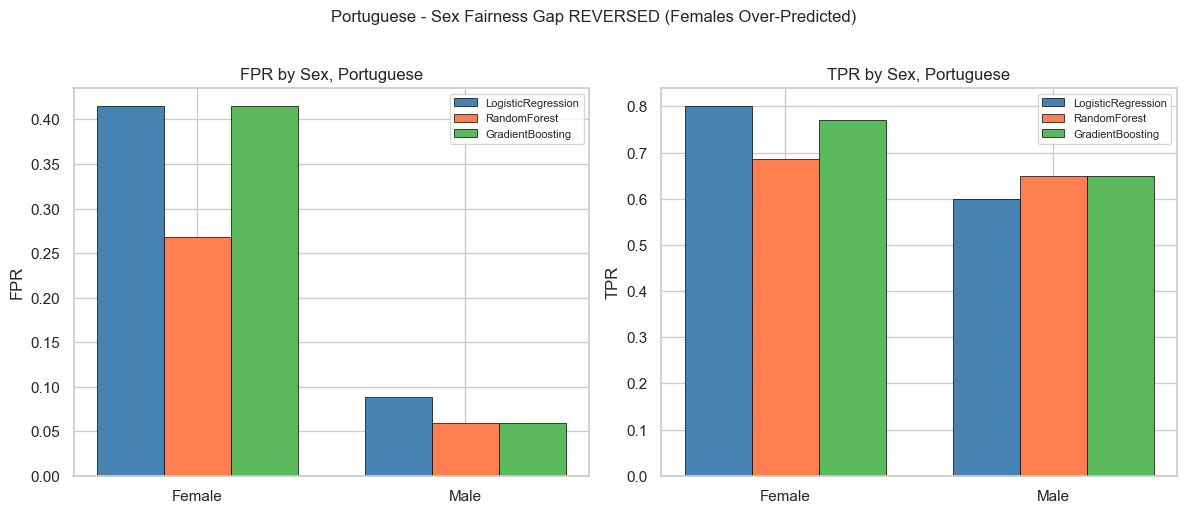

In [6]:
x=np.arange(2); width=0.25
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
for i,name in enumerate(MODELS_NB.keys()):
    fm=all_results['portuguese']['results'][name]['fairness_sex']
    fprs=[fm.get(g,{}).get('fpr',0) for g in [0,1]]
    tprs=[fm.get(g,{}).get('tpr',0) for g in [0,1]]
    ax1.bar(x+i*width,fprs,width,label=name,color=MODEL_COLORS[name],edgecolor='black',linewidth=0.5)
    ax2.bar(x+i*width,tprs,width,label=name,color=MODEL_COLORS[name],edgecolor='black',linewidth=0.5)
for ax,metric in [(ax1,'FPR'),(ax2,'TPR')]:
    ax.set_xticks(x+width); ax.set_xticklabels(['Female','Male'])
    ax.set_title(f'{metric} by Sex, Portuguese',fontsize=12); ax.set_ylabel(metric); ax.legend(fontsize=8)
plt.suptitle('Portuguese - Sex Fairness Gap REVERSED (Females Over-Predicted)',fontsize=12,y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/student_portuguese_sex_fairness.png',dpi=150,bbox_inches='tight')
plt.show()

## 5. Demographic Parity Difference by Sex

Gap reversal visible, Math males positive DP, Portuguese males negative DP.

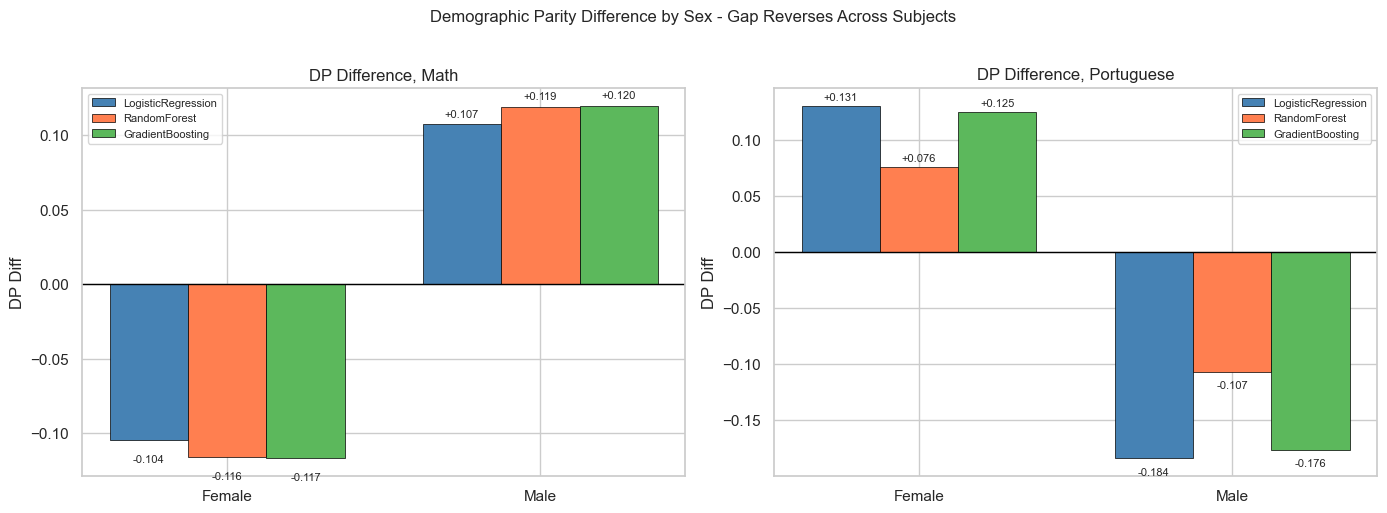

Math: males over-predicted | Portuguese: females over-predicted, gap reversal


In [7]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,subject in zip(axes,['math','portuguese']):
    x=np.arange(2); width=0.25
    for i,name in enumerate(MODELS_NB.keys()):
        fm=all_results[subject]['results'][name]['fairness_sex']
        dps=[fm.get(g,{}).get('dp_diff',0) for g in [0,1]]
        bars=ax.bar(x+i*width,dps,width,label=name,color=MODEL_COLORS[name],edgecolor='black',linewidth=0.5)
        for bar,val in zip(bars,dps):
            ax.text(bar.get_x()+bar.get_width()/2,val+(0.005 if val>=0 else -0.015),f'{val:+.3f}',ha='center',fontsize=8)
    ax.axhline(y=0,color='black',linewidth=1)
    ax.set_xticks(x+width); ax.set_xticklabels(['Female','Male'])
    ax.set_title(f'DP Difference, {subject.capitalize()}',fontsize=12)
    ax.set_ylabel('DP Diff'); ax.legend(fontsize=8)
plt.suptitle('Demographic Parity Difference by Sex - Gap Reverses Across Subjects',fontsize=12,y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/student_demographic_parity.png',dpi=150,bbox_inches='tight')
plt.show()
print('Math: males over-predicted | Portuguese: females over-predicted, gap reversal')

## 6. Feature Importance, Gradient Boosting

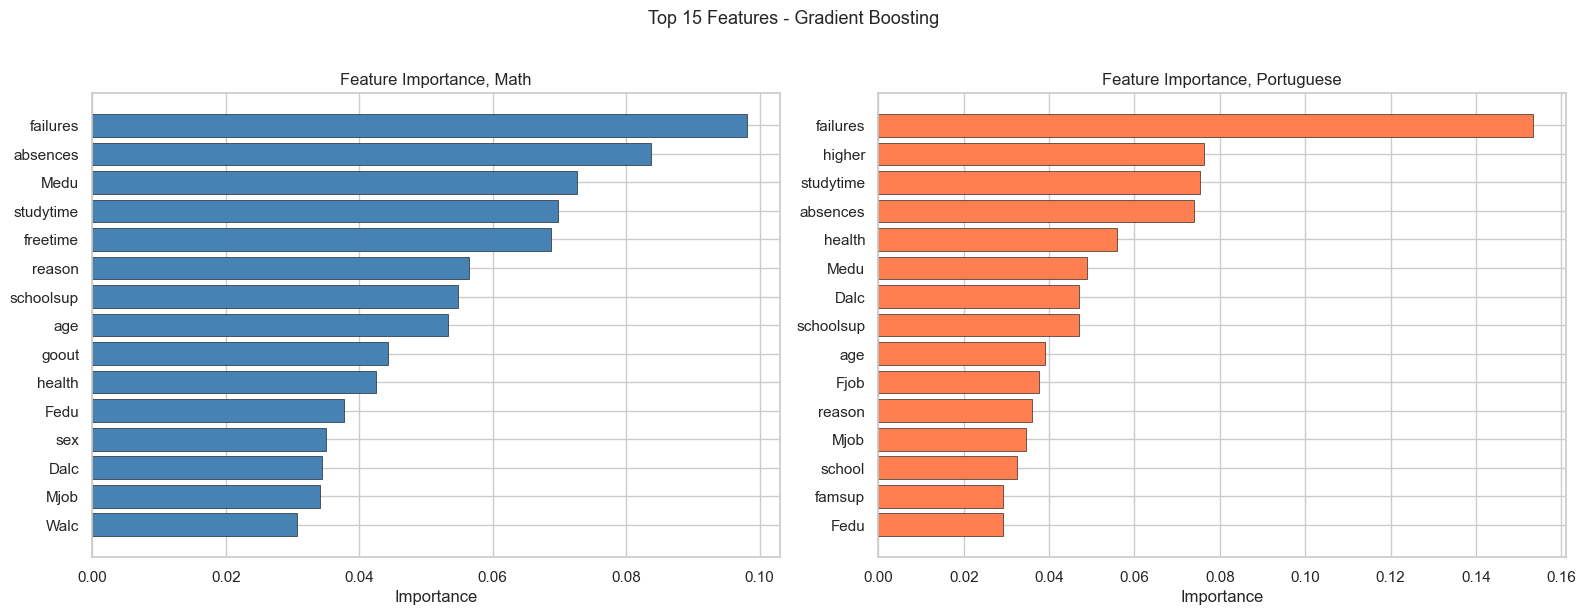

In [8]:
fig,axes=plt.subplots(1,2,figsize=(16,6))
for ax,subject in zip(axes,datasets.keys()):
    ds=datasets[subject]; X=ds['X'].values; y=ds['y'].values
    model=GradientBoostingClassifier(n_estimators=100,random_state=42)
    model.fit(X,y)
    importances=model.feature_importances_; feat_names=list(ds['X'].columns)
    top_idx=np.argsort(importances)[::-1][:15]
    ax.barh([feat_names[i] for i in top_idx[::-1]],importances[top_idx[::-1]],
            color=SUBJECT_COLORS[subject],edgecolor='black',linewidth=0.4)
    ax.set_title(f'Feature Importance, {subject.capitalize()}',fontsize=12)
    ax.set_xlabel('Importance')
plt.suptitle('Top 15 Features - Gradient Boosting',fontsize=13,y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/student_feature_importance.png',dpi=150,bbox_inches='tight')
plt.show()

## 7. Confusion Matrices, Best Model Per Subject

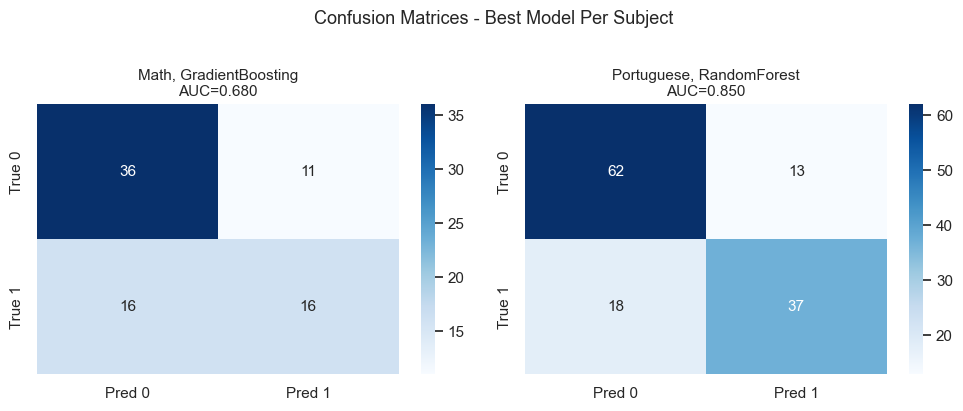

In [9]:
fig,axes=plt.subplots(1,2,figsize=(10,4))
for ax,subject in zip(axes,['math','portuguese']):
    best_name=max(all_results[subject]['results'].items(),key=lambda x: x[1]['auc'])[0]
    res=all_results[subject]['results'][best_name]
    cm=confusion_matrix(res['y_test'],res['y_pred'])
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax,
                xticklabels=['Pred 0','Pred 1'],yticklabels=['True 0','True 1'])
    ax.set_title(f'{subject.capitalize()}, {best_name}\nAUC={res["auc"]:.3f}',fontsize=11)
plt.suptitle('Confusion Matrices - Best Model Per Subject',fontsize=13,y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/student_confusion_matrices.png',dpi=150,bbox_inches='tight')
plt.show()

## 8. Disparate Impact Ratio by Sex

All DIR ratios below the 0.8 four-fifths convention across both subjects and all models.

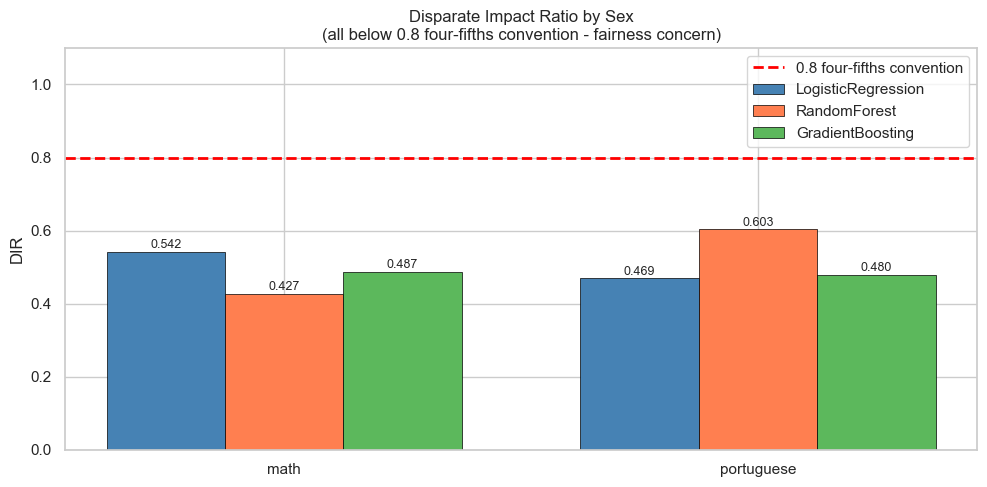

All DIR < 0.8 four-fifths convention, Stage 2 ThresholdOptimizer needed


In [10]:
dir_data=[]
for subject in ['math','portuguese']:
    for name in MODELS_NB.keys():
        fm=all_results[subject]['results'][name]['fairness_sex']
        if 0 in fm and 1 in fm:
            f_rate=fm[0]['pos_rate']; m_rate=fm[1]['pos_rate']
            dir_r=min(f_rate,m_rate)/max(f_rate,m_rate) if max(f_rate,m_rate)>0 else 1
            dir_data.append({'Subject':subject,'Model':name,'DIR':dir_r})
dir_df=pd.DataFrame(dir_data)
subjects=['math','portuguese']; x=np.arange(len(subjects)); width=0.25
fig,ax=plt.subplots(figsize=(10,5))
for i,name in enumerate(MODELS_NB.keys()):
    dirs=[dir_df[(dir_df['Subject']==s)&(dir_df['Model']==name)]['DIR'].values[0] for s in subjects]
    bars=ax.bar(x+i*width,dirs,width,label=name,color=MODEL_COLORS[name],edgecolor='black',linewidth=0.5)
    for bar,val in zip(bars,dirs):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,f'{val:.3f}',ha='center',fontsize=9)
ax.axhline(y=0.8,color='red',linestyle='--',linewidth=2,label='0.8 four-fifths convention')
ax.set_xticks(x+width); ax.set_xticklabels(subjects)
ax.set_title('Disparate Impact Ratio by Sex\n(all below 0.8 four-fifths convention - fairness concern)',fontsize=12)
ax.set_ylabel('DIR'); ax.set_ylim(0,1.1); ax.legend()
plt.tight_layout()
plt.savefig('../figures/baseline/student_disparate_impact.png',dpi=150,bbox_inches='tight')
plt.show()
print('All DIR < 0.8 four-fifths convention, Stage 2 ThresholdOptimizer needed')

## 9. Fairness Metrics by Age Group

Age binned into young/older (15-18 vs 19-22). The older group is sparse (9 records in the Math test split, 8 in Portuguese), so its results are unreliable. Young students dominate both datasets.

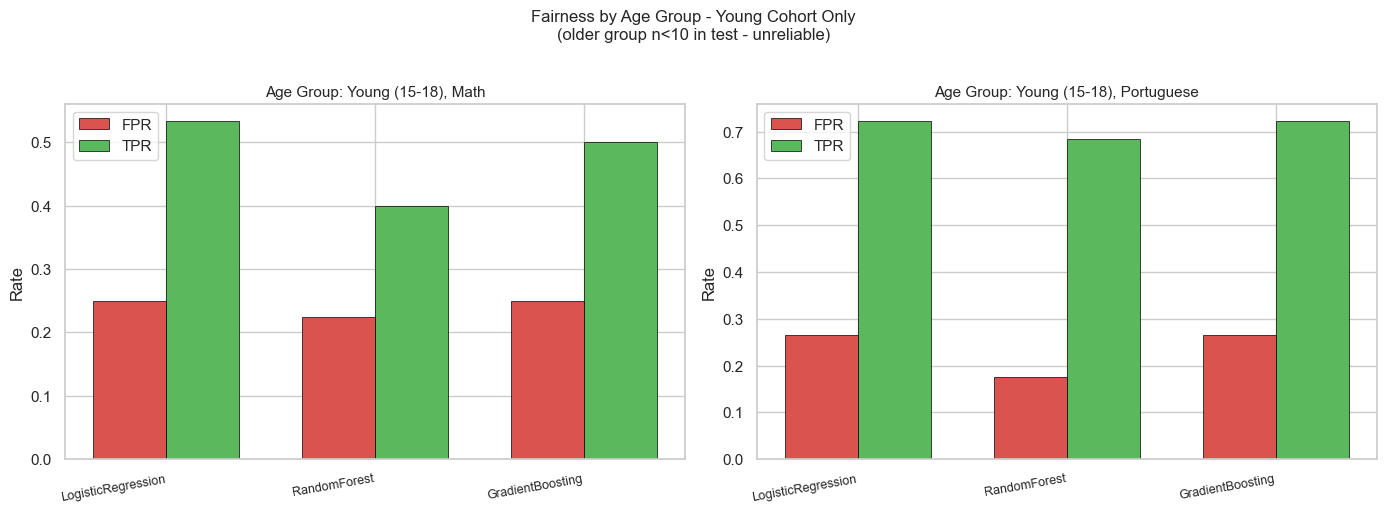

Older group too sparse for reliable metrics, young cohort results shown


In [11]:
age_data = []
for subject in ['math','portuguese']:
    for name in MODELS_NB.keys():
        fm = all_results[subject]['results'][name]['fairness_age']
        for grp, m in fm.items():
            age_data.append({'Subject':subject,'Model':name,'AgeGroup':grp,
                            'FPR':m['fpr'],'TPR':m['tpr'],'n':m['n']})

age_df = pd.DataFrame(age_data)
young_df = age_df[age_df['AgeGroup']=='young']

fig, axes = plt.subplots(1,2,figsize=(14,5))
for ax, subject in zip(axes,['math','portuguese']):
    sub = young_df[young_df['Subject']==subject]
    x = np.arange(len(MODELS_NB)); width = 0.35
    fprs = [sub[sub['Model']==n]['FPR'].values[0] for n in MODELS_NB.keys()]
    tprs = [sub[sub['Model']==n]['TPR'].values[0] for n in MODELS_NB.keys()]
    ax.bar(x-width/2, fprs, width, label='FPR', color='#d9534f', edgecolor='black', linewidth=0.5)
    ax.bar(x+width/2, tprs, width, label='TPR', color='#5cb85c', edgecolor='black', linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels(list(MODELS_NB.keys()), rotation=10, ha='right', fontsize=9)
    ax.set_title(f'Age Group: Young (15-18), {subject.capitalize()}', fontsize=11)
    ax.set_ylabel('Rate'); ax.legend()
plt.suptitle('Fairness by Age Group - Young Cohort Only\n(older group n<10 in test - unreliable)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/student_age_fairness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Older group too sparse for reliable metrics, young cohort results shown')

## 10. AUC vs Fairness Gap

The Portuguese models reach higher AUC than the Math models (0.824 to 0.850 against 0.673 to 0.680). Two of them also have larger DP gaps (0.184 and 0.176, against at most 0.120 in Math), but Portuguese random forest has the highest AUC and a gap of 0.107, level with the smallest in Math.

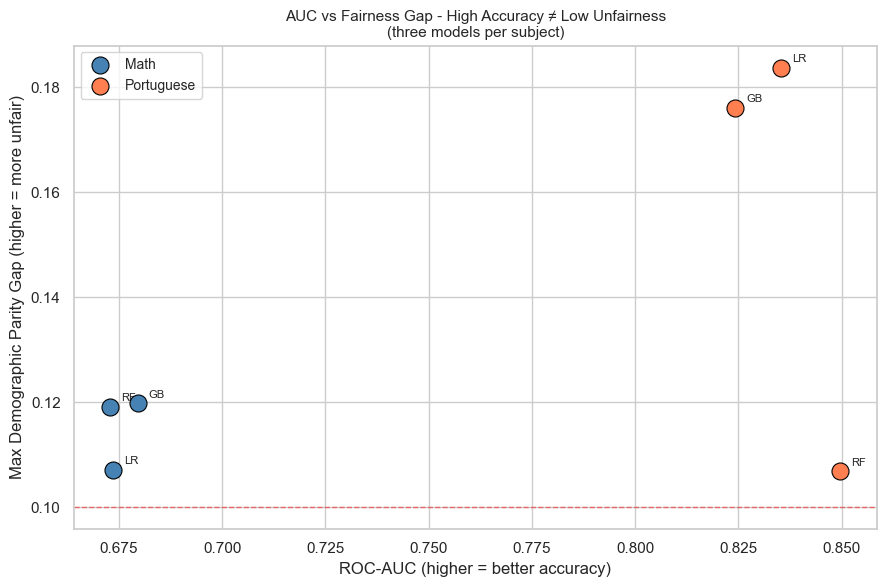

Math LR: AUC=0.674 max_DP=0.107
Math RF: AUC=0.673 max_DP=0.119
Math GB: AUC=0.680 max_DP=0.120
Portuguese LR: AUC=0.835 max_DP=0.184
Portuguese RF: AUC=0.850 max_DP=0.107
Portuguese GB: AUC=0.824 max_DP=0.176


In [12]:
SHORT = {'LogisticRegression': 'LR', 'RandomForest': 'RF', 'GradientBoosting': 'GB'}
scatter_data = [(subject.capitalize(), SHORT[m], r['auc'], r['max_dp'])
                for subject in ['math', 'portuguese'] for m, r in all_results[subject]['results'].items()]

sdf = pd.DataFrame(scatter_data, columns=['Subject','Model','AUC','max_DP'])
SUBJ_COLORS = {'Math':'steelblue','Portuguese':'coral'}

fig, ax = plt.subplots(figsize=(9,6))
for subject, color in SUBJ_COLORS.items():
    subset = sdf[sdf['Subject']==subject]
    ax.scatter(subset['AUC'], subset['max_DP'], s=150,
               color=color, label=subject, edgecolor='black', linewidth=0.8, zorder=5)
    for _, row in subset.iterrows():
        ax.annotate(f'{row.Model}', (row.AUC, row.max_DP),
                    textcoords='offset points', xytext=(8,4), fontsize=8)
ax.set_xlabel('ROC-AUC (higher = better accuracy)', fontsize=12)
ax.set_ylabel('Max Demographic Parity Gap (higher = more unfair)', fontsize=12)
ax.set_title('AUC vs Fairness Gap - High Accuracy ≠ Low Unfairness\n'
             '(three models per subject)', fontsize=11)
ax.legend(fontsize=10)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1, alpha=0.5, label='DP=0.1 threshold')
plt.tight_layout()
plt.savefig('../figures/baseline/student_auc_vs_fairness.png', dpi=150, bbox_inches='tight')
plt.show()
for row in sdf.itertuples():
    print(f'{row.Subject} {row.Model}: AUC={row.AUC:.3f} max_DP={row.max_DP:.3f}')

## 11. Cross-Validation Stability, Dataset Size Effect

Five-fold cross-validated AUC on each subject's training split. Math's training split has 316 records and Portuguese's 519, so Math's folds are smaller and its fold-to-fold spread is expected to be wider; the cell prints the values it plots.

math LR: CV AUC 0.677 ± 0.076


math RF: CV AUC 0.661 ± 0.084


math GB: CV AUC 0.644 ± 0.091
portuguese LR: CV AUC 0.759 ± 0.037


portuguese RF: CV AUC 0.770 ± 0.033


portuguese GB: CV AUC 0.746 ± 0.054


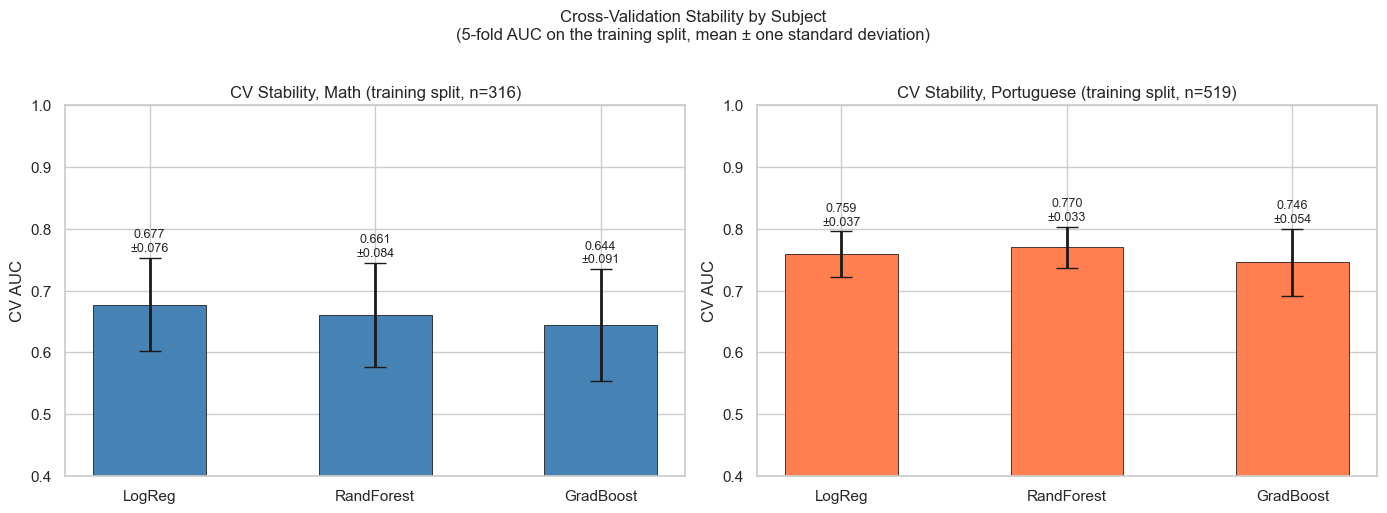

LR fold std: Math 0.076 vs Portuguese 0.037 (2.1x)


In [13]:
import warnings; warnings.filterwarnings('ignore')
from sklearn.model_selection import cross_val_score

# 5-fold cross-validated AUC on each subject's training split (same split as above)
cv_data = {}
train_sizes = {}
for subject in ['math', 'portuguese']:
    Xs = all_results[subject]['X'].values; ys = all_results[subject]['y'].values
    Xs_train, _, ys_train, _ = train_test_split(Xs, ys, test_size=0.2, random_state=42, stratify=ys)
    Xs_train_sc = StandardScaler().fit_transform(Xs_train)
    train_sizes[subject] = len(ys_train)
    cv_data[subject] = {}
    for short, (name, model) in zip(['LR', 'RF', 'GB'], MODELS_NB.items()):
        scores = cross_val_score(model, Xs_train_sc if name == 'LogisticRegression' else Xs_train,
                                 ys_train, cv=5, scoring='roc_auc')
        cv_data[subject][short] = (scores.mean(), scores.std())
        print(f'{subject} {short}: CV AUC {scores.mean():.3f} ± {scores.std():.3f}')

model_names = ['LR','RF','GB']
x = np.arange(len(model_names)); width = 0.35

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,5))

for ax, subject, color in [(ax1,'math','steelblue'),(ax2,'portuguese','coral')]:
    means = [cv_data[subject][m][0] for m in model_names]
    stds = [cv_data[subject][m][1] for m in model_names]
    bars = ax.bar(x, means, width=0.5, color=color, edgecolor='black', linewidth=0.5,
                  yerr=stds, capsize=8, error_kw={'linewidth':2})
    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x()+bar.get_width()/2, mean+std+0.01,
                f'{mean:.3f}\n±{std:.3f}', ha='center', fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(['LogReg','RandForest','GradBoost'])
    ax.set_title(f'CV Stability, {subject.capitalize()} (training split, n={train_sizes[subject]})', fontsize=12)
    ax.set_ylabel('CV AUC'); ax.set_ylim(0.4, 1.0)

plt.suptitle('Cross-Validation Stability by Subject\n(5-fold AUC on the training split, mean ± one standard deviation)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/student_cv_stability.png', dpi=150, bbox_inches='tight')
plt.show()
ratio = cv_data['math']['LR'][1] / cv_data['portuguese']['LR'][1]
print(f"LR fold std: Math {cv_data['math']['LR'][1]:.3f} vs Portuguese {cv_data['portuguese']['LR'][1]:.3f} ({ratio:.1f}x)")

## 12. Key Findings

**Math (n=395):** AUC=0.680 (GB). Males over-predicted (DP=+0.107 to +0.120).

**Portuguese (n=649):** AUC=0.850 (RF). Sex gap reversed, females over-predicted.

**Key FAPE finding:** Sex bias direction reverses between Math and Portuguese, cross-subject inconsistency FAPE's cross-domain audit is designed to detect.

**DIR below the 0.8 four-fifths convention:** All disparate impact ratios below 0.8 across both subjects and all models.

**Stage 2 ThresholdOptimizer target:** Reduce sex-based DP gaps from 0.107 to 0.184 toward 0.05.